In [36]:
import numpy as np
import matplotlib.pyplot as plt

import torch

from transformers import AutoModelForCausalLM, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)

tokenizer.pad_token_id = tokenizer.eos_token_id
#
model.eval();

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

# Implant hooks at attention layer

In [28]:
activations = {}
num_embd = model.config.n_embd
num_layers = model.config.n_layer

def implant_hook(layer_number):
    def hook(module, inputs, output):
        # output: [batch, seq, 3*num_embd]
        qkv = output.detach()
        q, k, v = qkv.split(num_embd, dim=-1)

        activations[f"attn_{layer_number}_q"] = q.cpu().numpy()
        activations[f"attn_{layer_number}_k"] = k.cpu().numpy()
        activations[f"attn_{layer_number}_v"] = v.cpu().numpy()

        return None
    return hook

# remove old hooks
if "handles" in globals() and handles is not None:
    for h in handles:
        h.remove()

handles = [
    model.transformer.h[i].attn.c_attn.register_forward_hook(implant_hook(i))
    for i in range(num_layers)
]

# Select text

In [94]:
# list of words for RSA
words = [ 'galaxy','asteroid','comet','cosmos','space','sun','planet','moon','star','orbit',
          'ceiling','sofa','couch','carpet','door','window','lamp','chair','table','rug','bed','floor','wall',
          'pear','grape','banana','cherry','peach','apple','seed','jelly','orange','lime','fruit'
        ]

In [95]:
# create a group mask based on word order
group = np.array([ [1,1,1,1,1,1,1,1,1,1,
                    2,2,2,2,2,2,2,2,2,2,2,2,2,
                    3,3,3,3,3,3,3,3,3,3,3
                    ] ])

g = group.ravel()
same = (g[:,None] == g[None,:])
upper = np.triu(np.ones_like(same, dtype=bool), 1)

same_mask = same & upper
diff_mask = ~same & upper

In [97]:
# create a batch with all target tokens at the end
batch = torch.zeros((len(words),5),dtype=torch.long)

for i,w in enumerate(words):
  batch[i,:] = torch.tensor(tokenizer.encode(f'The next word is {w}'))

batch.to(device);

# Pass the text through the model

In [46]:
with torch.no_grad(): model(batch.to(device))

In [47]:
activations['attn_0_q'].shape

(34, 5, 1280)

# Calculate cosine similarities and RSA for each layer

In [74]:
N = len(words)

selectivity_indices = np.full((3, num_layers), np.nan, dtype=float)
cossim_mat = np.full((3, N, N), np.nan, dtype=float)
RSA = np.zeros((3,num_layers))
u = np.zeros((3,N*(N-1)//2), dtype=float)

for layeri in range(num_layers):

  # Loop over each of the bolcks - Q, K, V

  for i, qkv in enumerate(["q", "k", "v"]):

    #cosine-similarities
    X = activations[f"attn_{layeri}_{qkv}"][:, -1, :].astype(np.float32, copy=True)
    X /= np.linalg.norm(X, axis=-1, keepdims=True) + 1e-12  # safe normalize

    cossim = X @ X.T
    cossim_mat[i] = cossim

    #selectivity_indices
    selectivity_indices[i, layeri] = (
        cossim[same_mask].mean() / (cossim[diff_mask].mean() + 1e-12)
    )

    # RSA
    # extract upper triangular elements
    u[i] = cossim[np.nonzero(np.triu(cossim, 1))]

  # Pearson correlation to get RSA
  RSA[0, layeri] = np.corrcoef(u[0], u[1])[0, 1] # Q vs K
  RSA[1, layeri] = np.corrcoef(u[0], u[2])[0, 1] # Q vs V
  RSA[2, layeri] = np.corrcoef(u[1], u[2])[0, 1] # K vs V



[]

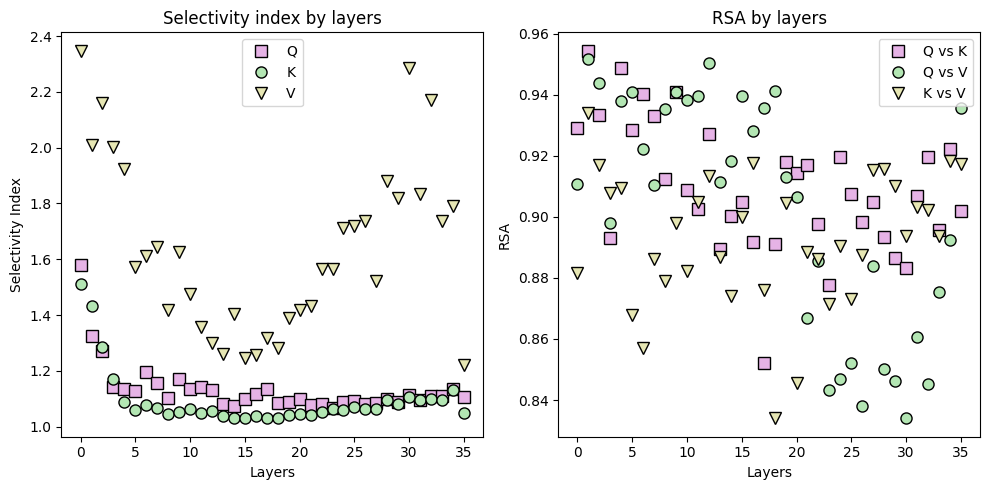

In [93]:
# Visualize
fig, ax = plt.subplots(1,2, figsize=(10,5))

markers = ['ks','ko','kv']
facecolors = [[.9,.7,.9],[.7,.9,.7],[.9,.9,.7]]
RSA_labels = ['Q vs K', 'Q vs V', 'K vs V']

# Plot layer vs slectivity index
for i, qkv in enumerate(["Q", "K", "V"]):
  ax[0].plot(selectivity_indices[i], markers[i], markersize=8, markerfacecolor=facecolors[i],label=f'{qkv}')
  ax[1].plot(RSA[i], markers[i], markersize=8, markerfacecolor=facecolors[i],label=RSA_labels[i])

ax[0].set(xlabel='Layers', ylabel='Selectivity Index', title='Selectivity index by layers')
ax[1].set(xlabel='Layers', ylabel='RSA', title='RSA by layers')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.plot()